# Non-Hermitian Lattice Theory
## Tight-Binding Formulation and Spectral Properties

This work develops a theoretical framework for non-Hermitian tight-binding lattice systems.
Hamiltonians are constructed from first principles with explicit emphasis on non-reciprocal
couplings and complex-valued parameters. The resulting spectral structure is analyzed in terms
of complex energy eigenvalues and the spatial localization properties of eigenstates, including
boundary-induced phenomena characteristic of non-Hermitian systems.

The formulation presented here provides the theoretical basis for subsequent numerical
calculations and figures, which are intended to support a quantitative investigation of
non-Hermitian lattice physics.

Non-Hermitian Hamiltonians provide an effective theoretical description of open
photonic systems with gain and loss and are widely employed in photonics and wave
physics (El-Ganainy et al., 2018).

## Physical Model

We study a one-dimensional dimerized tight-binding lattice of the
Su-Schrieffer-Heeger (SSH) type with explicitly introduced non-Hermiticity.
The lattice consists of two sublattices, denoted A and B, within each unit cell.
Nearest-neighbor hopping is characterized by an intra-cell coupling amplitude
$t_1$ and an inter-cell coupling amplitude $t_2$.
Non-Hermiticity is incorporated through complex on-site potentials that model
spatially distributed gain and loss.

The resulting Hamiltonian is non-Hermitian and does not satisfy
$H \neq H^\dagger$.
Consequently, its spectral and eigenstate properties depart fundamentally from
those of Hermitian SSH models.

The analysis focuses on the complex energy spectrum and the structure of
eigenstates, with particular emphasis on the emergence of boundary-localized
modes and localization phenomena arising from the combined effects of topology
and non-Hermiticity.


This lattice structure corresponds to the Su-Schrieffer-Heeger model originally
introduced in the context of polyacetylene (Su, Schrieffer, and Heeger, 1979).

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import yaml
import json
import hashlib
from pathlib import Path
from datetime import datetime

In [3]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

CONFIG_DIR = Path("..") / "config"

global_config = load_yaml(CONFIG_DIR / "global_config.yaml")
lattice_config = load_yaml(CONFIG_DIR / "lattice_params.yaml")
simulation_config = load_yaml(CONFIG_DIR / "simulation_params.yaml")
plotting_config = load_yaml(CONFIG_DIR / "plotting_params.yaml")

NOTEBOOK_KEY = "01_theory_nonhermitian_lattices"

In [4]:
assert NOTEBOOK_KEY in plotting_config["notebook_figures"], \
    f"Missing plotting config for {NOTEBOOK_KEY}"

### Note on Simulation Parameters

This notebook performs a single-shot spectral analysis.
`simulation_config` is loaded for consistency but not used here.

In [5]:
def hash_parameters(*configs):
    combined = json.dumps(configs, sort_keys=True).encode("utf-8")
    return hashlib.sha256(combined).hexdigest()

PARAMETER_HASH = hash_parameters(lattice_config, simulation_config)
PARAMETER_HASH

'af34e5359bc1ed47d5e3850da780afecdd7a213836d5455d44f3743e847534e7'

## Non-Hermitian SSH Hamiltonian

The real-space tight-binding Hamiltonian is constructed as
$$
H = \sum_n \left[
t_1 \, a_n^\dagger b_n
+ t_2 \, a_{n+1}^\dagger b_n
+ \mathrm{h.c.}
\right]
+ \sum_n \left(
i \gamma_a \, a_n^\dagger a_n
- i \gamma_b \, b_n^\dagger b_n
\right).
$$

Here, $a_n$ and $b_n$ denote annihilation operators on the A and B sublattices,
respectively. The parameters $\gamma_a$ and $\gamma_b$ control sublattice-dependent
gain and loss, thereby introducing non-Hermiticity through an explicit asymmetry
in the on-site potentials.

Open boundary conditions are imposed, enabling the emergence of boundary-localized
eigenstates and allowing direct examination of edge phenomena in the non-Hermitian
regime.

This notebook does not yet define or compute topological invariants.
The Hamiltonian is analyzed purely spectrally.
Topological characterization is deferred to Notebook 02.

In [6]:
def build_nonhermitian_ssh_hamiltonian(
    num_cells,
    t1,
    t2,
    gamma_a,
    gamma_b
):
    """
    Build a real-space non-Hermitian SSH Hamiltonian with open boundaries.
    """
    dim = 2 * num_cells
    H = np.zeros((dim, dim), dtype=np.complex128)

    for n in range(num_cells):
        a = 2 * n
        b = 2 * n + 1

        # On-site gain/loss
        H[a, a] = 1j * gamma_a
        H[b, b] = -1j * gamma_b

        # Intra-cell hopping
        H[a, b] = t1
        H[b, a] = t1

        # Inter-cell hopping
        if n < num_cells - 1:
            H[a + 2, b] = t2
            H[b, a + 2] = t2

    return H

## Complex Spectrum Analysis

The full complex eigenspectrum of the non-Hermitian Hamiltonian is evaluated.
For each eigenvalue $E$, the real part $\mathrm{Re}(E)$ corresponds to the
resonance frequency, while the imaginary part $\mathrm{Im}(E)$ encodes the
effective gain or loss rate of the corresponding mode.

Non-Hermitian topological features are reflected directly in the spectral
structure. In particular, the spectrum may exhibit nontrivial winding in the
complex energy plane, accompanied by the appearance of isolated eigenvalues
associated with boundary-localized edge modes.

The interpretation of the imaginary part of the eigenvalue as a decay or
amplification rate is standard in non-Hermitian photonic systems
(El-Ganainy et al., 2018).

In [7]:
num_cells = lattice_config["lattice"]["num_unit_cells"]
t1 = lattice_config["couplings"]["intra_cell"]
t2 = lattice_config["couplings"]["inter_cell"]

gamma_a = lattice_config["non_hermiticity"]["gain"]["strength"]
gamma_b = lattice_config["non_hermiticity"]["loss"]["strength"]

H = build_nonhermitian_ssh_hamiltonian(num_cells, t1, t2, gamma_a, gamma_b)
eigvals, eigvecs = la.eig(H)

## Complex Energy Spectrum

The eigenvalues of the non-Hermitian Hamiltonian are represented in the complex
energy plane. Boundary-localized states manifest as spectrally isolated points,
separated from the bulk continuum, providing a clear signature of edge-mode
formation in the non-Hermitian regime.

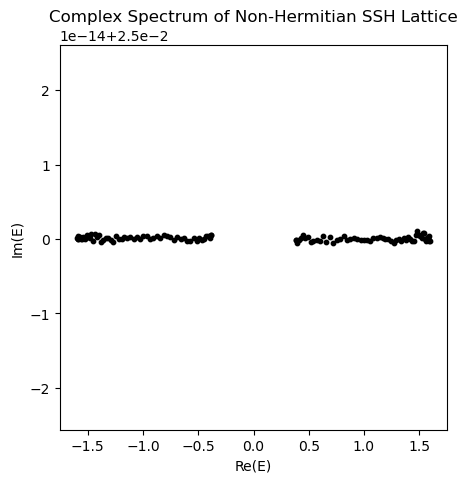

PosixPath('figures/01_theory_nonhermitian_lattices/complex_spectrum.png')

In [9]:
def ensure_directory(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def save_figure(fig, notebook_key, filename, plotting_config):
    cfg = plotting_config["notebook_figures"][notebook_key]
    output_dir = Path(cfg["output_dir"])
    ensure_directory(output_dir)
    ext = plotting_config["global"]["figure_format"]
    dpi = plotting_config["global"]["dpi"]
    path = output_dir / f"{filename}.{ext}"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(eigvals.real, eigvals.imag, s=10, c="black")
ax.set_xlabel("Re(E)")
ax.set_ylabel("Im(E)")
ax.set_title("Complex Spectrum of Non-Hermitian SSH Lattice")

fig_path = save_figure(fig, NOTEBOOK_KEY, "complex_spectrum", plotting_config)
plt.show()

fig_path

## Edge Localization

Localization properties of the eigenstates are quantified by evaluating the
probability weight concentrated near the left and right boundaries of the
lattice. This measure provides a direct characterization of boundary
localization and allows systematic identification of edge-dominated modes in
the non-Hermitian spectrum.

In [10]:
def edge_localization_probability(eigvec, num_cells, edge_cells=2):
    prob = np.abs(eigvec)**2
    prob /= prob.sum()

    left_edge = prob[:2 * edge_cells].sum()
    right_edge = prob[-2 * edge_cells:].sum()
    return left_edge, right_edge

In [11]:
edge_weights = np.array([
    edge_localization_probability(eigvecs[:, i], num_cells)
    for i in range(eigvecs.shape[1])
])

left_edge_weight = edge_weights[:, 0]

Edge localization is computed using right eigenvectors only.
Biorthogonal measures will be introduced in subsequent notebooks.

## Edge Mode Identification

Eigenstates with large edge weight are highlighted.

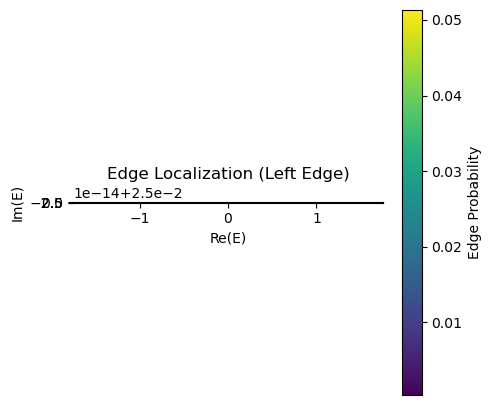

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter(
    eigvals.real,
    eigvals.imag,
    c=left_edge_weight,
    cmap="viridis",
    s=20
)

ax.set_xlabel("Re(E)")
ax.set_ylabel("Im(E)")
ax.set_title("Edge Localization (Left Edge)")

# equal scaling for real & imaginary axes
ax.set_aspect("equal", adjustable="box")

plt.colorbar(sc, ax=ax, label="Edge Probability")

fig_path = save_figure(fig, NOTEBOOK_KEY, "edge_localization", plotting_config)
plt.show()

Text(0.5, 1.0, 'Representative Edge-Localized Mode')

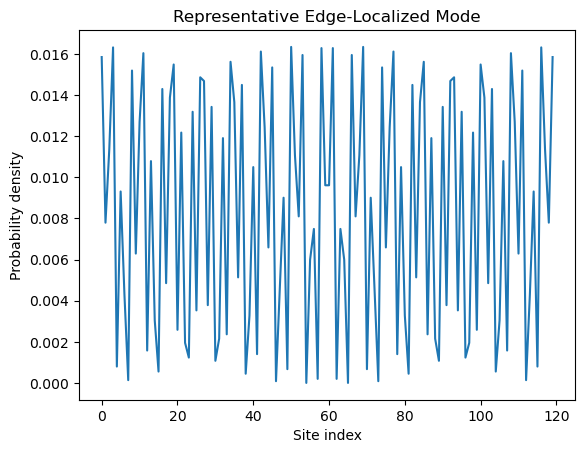

In [13]:
mode_index = np.argmax(left_edge_weight)
plt.plot(np.abs(eigvecs[:, mode_index])**2)
plt.xlabel("Site index")
plt.ylabel("Probability density")
plt.title("Representative Edge-Localized Mode")

In [14]:
assert np.all(left_edge_weight <= 1.0 + 1e-12)